# Data preprocessing

Notebook for dataset statistics, augmentation, and post-augmentation stats.
Classes: 0 car, 1 truck, 2 bus, 3 motor.

## YOLO label format
- One line per object: `class_id cx cy width height`
- `class_id`: 0-3 (car, truck, bus, motor)
- `cx`, `cy`, `width`, `height`: normalized to image size, range 0.0-1.0

In [8]:
from pathlib import Path
from collections import Counter
import random
import shutil
import cv2
import matplotlib.pyplot as plt

DATASET_DIR = Path(r"D:\2026\DATN\Data\dataset")
IMAGES_DIR = DATASET_DIR / "images"
LABELS_DIR = DATASET_DIR / "labels"

OUTPUT_AUG_DIR = Path(r"D:\2026\DATN\Data\dataset_aug")

CLASS_NAMES = {
    0: "car",
    1: "truck",
    2: "bus",
    3: "motor",
}

IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

In [9]:
def load_labels(label_path: Path):
    labels = []
    for line in label_path.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls_id = int(parts[0])
        x, y, w, h = map(float, parts[1:])
        labels.append((cls_id, x, y, w, h))
    return labels


def save_labels(label_path: Path, labels):
    lines = [
        f"{cls_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}"
        for cls_id, x, y, w, h in labels
    ]
    label_path.write_text("\n".join(lines))


def collect_pairs(images_dir: Path, labels_dir: Path):
    pairs = []
    for img_path in sorted(images_dir.iterdir()):
        if img_path.suffix.lower() not in IMAGE_EXTS:
            continue
        label_path = labels_dir / f"{img_path.stem}.txt"
        if label_path.exists():
            pairs.append((img_path, label_path))
    return pairs


def dataset_stats(images_dir: Path, labels_dir: Path):
    pairs = collect_pairs(images_dir, labels_dir)
    class_counts = Counter()
    for _, label_path in pairs:
        for cls_id, *_ in load_labels(label_path):
            class_counts[cls_id] += 1
    total_images = len(pairs)
    total_labels = sum(class_counts.values())
    return total_images, total_labels, class_counts


def print_stats(title: str, total_images: int, total_labels: int, class_counts: Counter):
    print("=" * 60)
    print(title)
    print(f"Total Images: {total_images}")
    print(f"Total Objects: {total_labels}")
    for cls_id, name in CLASS_NAMES.items():
        count = class_counts.get(cls_id, 0)
        ratio = (count / total_labels * 100) if total_labels else 0.0
        print(f"{cls_id} {name}: {count} ({ratio:.2f}%)")
    print("=" * 60)


def plot_class_distribution(class_counts: Counter, title: str):
    labels = [CLASS_NAMES[i] for i in CLASS_NAMES]
    values = [class_counts.get(i, 0) for i in CLASS_NAMES]
    total = sum(values)
    plt.figure(figsize=(6, 4))
    bars = plt.bar(labels, values, color="#3b82f6")
    for bar, value in zip(bars, values):
        ratio = (value / total * 100) if total else 0.0
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{ratio:.1f}%", ha="center", va="bottom")
    plt.title(title)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


def draw_sample_with_bboxes(
    images_dir: Path,
    labels_dir: Path,
    sample_index: int = 0,
    image_path: str | Path | None = None,
    label_path: str | Path | None = None,
    ):
    if image_path:
        img_path = Path(image_path)
        if label_path:
            lbl_path = Path(label_path)
        else:
            lbl_path = labels_dir / f"{img_path.stem}.txt"
    else:
        pairs = collect_pairs(images_dir, labels_dir)
        if not pairs:
            print("No image/label pairs found.")
            return
        img_path, lbl_path = pairs[sample_index % len(pairs)]
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"Failed to read image: {img_path}")
        return
    if not lbl_path.exists():
        print(f"Label not found: {lbl_path}")
        return
    labels = load_labels(lbl_path)
    h, w = img.shape[:2]
    for cls_id, x, y, bw, bh in labels:
        x1 = int((x - bw / 2) * w)
        y1 = int((y - bh / 2) * h)
        x2 = int((x + bw / 2) * w)
        y2 = int((y + bh / 2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        label = CLASS_NAMES.get(cls_id, str(cls_id))
        cv2.putText(img, label, (x1, max(0, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title(f"Sample: {img_path.name}")
    plt.axis("off")
    plt.show()

Before augmentation
Total Images: 864
Total Objects: 6435
0 car: 4699 (73.02%)
1 truck: 88 (1.37%)
2 bus: 56 (0.87%)
3 motor: 1592 (24.74%)


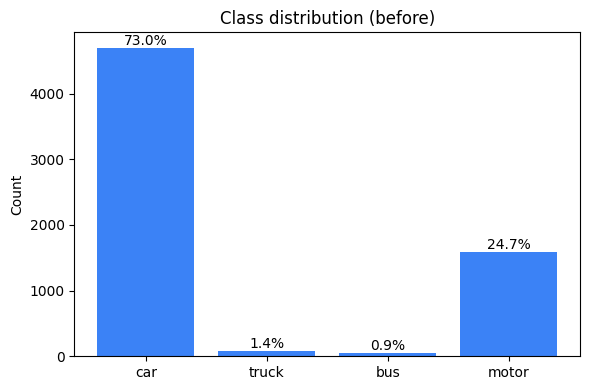

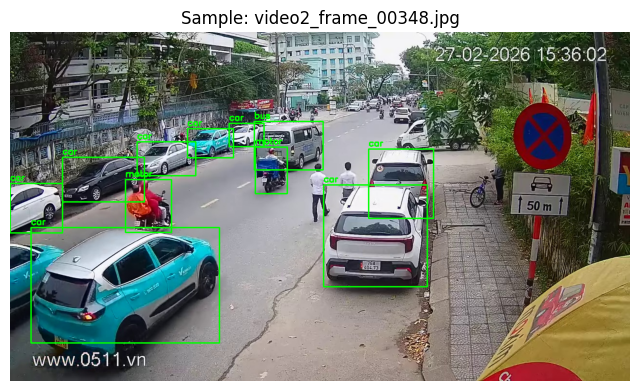

In [10]:
before_stats = dataset_stats(IMAGES_DIR, LABELS_DIR)
print_stats("Before augmentation", *before_stats)
_, _, before_counts = before_stats
plot_class_distribution(before_counts, "Class distribution (before)")
IMAGE_SAMPLE_PATH = r"D:\\2026\\DATN\\Data\\dataset\\images\\video2_frame_00348.jpg"
draw_sample_with_bboxes(IMAGES_DIR, LABELS_DIR, sample_index=0, image_path=IMAGE_SAMPLE_PATH)

In [12]:
def adjust_brightness(img, factor: float):
    return cv2.convertScaleAbs(img, alpha=factor, beta=0)


def flip_horizontal(img, labels):
    flipped = cv2.flip(img, 1)
    new_labels = []
    for cls_id, x, y, w, h in labels:
        new_x = 1.0 - x
        new_labels.append((cls_id, new_x, y, w, h))
    return flipped, new_labels


def augment_dataset(
    images_dir: Path,
    labels_dir: Path,
    output_root: Path,
    motor_only_copies: int = 1,
    other_copies: int = 3,
    brightness_prob: float = 0.7,
    flip_prob: float = 0.5,
    seed: int = 42,
):
    pairs = collect_pairs(images_dir, labels_dir)
    out_images = output_root / "images"
    out_labels = output_root / "labels"
    out_images.mkdir(parents=True, exist_ok=True)
    out_labels.mkdir(parents=True, exist_ok=True)

    for img_path, label_path in pairs:
        dst_img = out_images / f"{img_path.stem}{img_path.suffix.lower()}"
        dst_lbl = out_labels / f"{img_path.stem}.txt"
        if not dst_img.exists():
            shutil.copy2(img_path, dst_img)
        if not dst_lbl.exists():
            shutil.copy2(label_path, dst_lbl)

    random.seed(seed)
    aug_index = 1

    for img_path, label_path in pairs:
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        labels = load_labels(label_path)
        class_ids = {cls_id for cls_id, *_ in labels}
        copies_for_image = motor_only_copies if class_ids == {3} else other_copies

        for _ in range(copies_for_image):
            aug_img = img.copy()
            aug_labels = list(labels)

            if random.random() < brightness_prob:
                factor = random.uniform(0.6, 1.4)
                aug_img = adjust_brightness(aug_img, factor)

            if random.random() < flip_prob:
                aug_img, aug_labels = flip_horizontal(aug_img, aug_labels)

            base = f"{img_path.stem}_aug{aug_index:04d}"
            aug_index += 1

            out_img = out_images / f"{base}{img_path.suffix.lower()}"
            out_lbl = out_labels / f"{base}.txt"

            if out_img.exists() or out_lbl.exists():
                continue

            cv2.imwrite(str(out_img), aug_img)
            save_labels(out_lbl, aug_labels)

    print(f"Augmented images created: {aug_index - 1}")

In [13]:
import shutil

def clear_output_directory(output_root: Path):
    if output_root.exists():
        shutil.rmtree(output_root)
    output_root.mkdir(parents=True, exist_ok=True)

# Clear output directory before augmentation
clear_output_directory(OUTPUT_AUG_DIR)

MOTOR_ONLY_COPIES = 1
OTHER_COPIES = 3
augment_dataset(
    IMAGES_DIR,
    LABELS_DIR,
    OUTPUT_AUG_DIR,
    motor_only_copies=MOTOR_ONLY_COPIES,
    other_copies=OTHER_COPIES,
)
after_stats = dataset_stats(OUTPUT_AUG_DIR / "images", OUTPUT_AUG_DIR / "labels")

Augmented images created: 2556


After augmentation
Total Images: 3420
Total Objects: 25666
0 car: 18796 (73.23%)
1 truck: 352 (1.37%)
2 bus: 224 (0.87%)
3 motor: 6294 (24.52%)


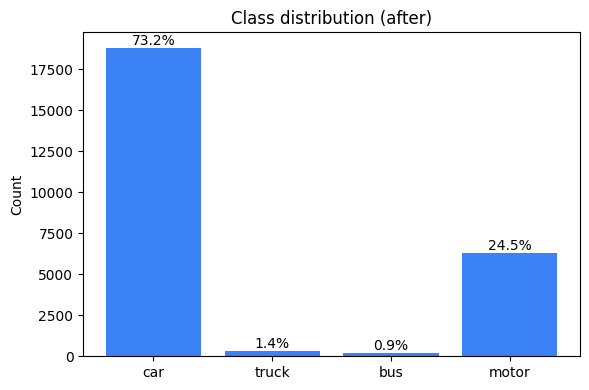

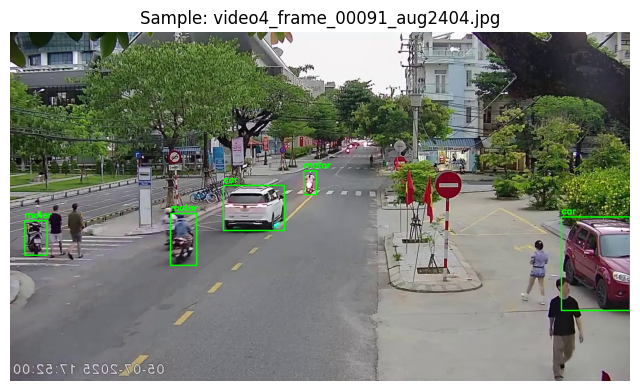

In [15]:
print_stats("After augmentation", *after_stats)
_, _, after_counts = after_stats
plot_class_distribution(after_counts, "Class distribution (after)")
IMAGE_SAMPLE_PATH_AUG = r"D:\\2026\\DATN\\Data\\dataset_aug\\images\\video4_frame_00091_aug2404.jpg"
draw_sample_with_bboxes(OUTPUT_AUG_DIR / "images", OUTPUT_AUG_DIR / "labels", sample_index=0, image_path=IMAGE_SAMPLE_PATH_AUG)